# Notebook 02 — Export Slice Images for Power BI Dashboard

## Objective

This notebook exports representative microCT slice images for the Power BI dashboard.

It reuses:

- the original microCT TIFF stack from Project 02,
- the segmented phase labels from Project 02,
- pore and resin masks from Project 02,
- anomaly results prepared in Project 05.

The goal is to create lightweight PNG images that can be linked to `slice_id` and displayed in Power BI as part of a slice-level dashboard explorer.

## Main outputs

- Original slice images.
- Segmentation overlay images.
- Pore mask images.
- Resin mask images.
- `image_index.csv`, linking each exported image to its `slice_id` and image type.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Project paths
PROJECT_ROOT = Path("..").resolve()
PORTFOLIO_ROOT = PROJECT_ROOT.parents[1]

PROJECT_02 = PORTFOLIO_ROOT / "projects" / "02_microct_subvolume_3d_analysis"

DASHBOARD_EXPORTS = PROJECT_ROOT / "data" / "dashboard_exports"

IMAGE_OUTPUT_DIR = DASHBOARD_EXPORTS / "slice_images"
IMAGE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project 05 root:", PROJECT_ROOT)
print("Project 02 path exists:", PROJECT_02.exists())
print("Dashboard exports:", DASHBOARD_EXPORTS)
print("Image output directory:", IMAGE_OUTPUT_DIR)

Project 05 root: C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi
Project 02 path exists: True
Dashboard exports: C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports
Image output directory: C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports\slice_images


In [2]:
# Input paths from Project 02

raw_stack_dir = PROJECT_02 / "data" / "raw" / "DatosSubV"

phase_labels_path = PROJECT_02 / "data" / "processed" / "phase_labels_3class.npy"
pores_mask_path = PROJECT_02 / "data" / "processed" / "pores_mask.npy"
resin_mask_path = PROJECT_02 / "data" / "processed" / "resin_mask_refined_ge50.npy"

# Dashboard tables from Notebook 01
dim_slice_path = DASHBOARD_EXPORTS / "dim_slice.csv"
fact_slice_features_path = DASHBOARD_EXPORTS / "fact_slice_features.csv"
fact_anomaly_results_path = DASHBOARD_EXPORTS / "fact_anomaly_results.csv"

input_paths = {
    "raw_stack_dir": raw_stack_dir,
    "phase_labels": phase_labels_path,
    "pores_mask": pores_mask_path,
    "resin_mask_refined": resin_mask_path,
    "dim_slice": dim_slice_path,
    "fact_slice_features": fact_slice_features_path,
    "fact_anomaly_results": fact_anomaly_results_path,
}

for name, path in input_paths.items():
    print(f"{name:25s} | exists: {path.exists()} | {path}")

raw_stack_dir             | exists: True | C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\raw\DatosSubV
phase_labels              | exists: True | C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\phase_labels_3class.npy
pores_mask                | exists: True | C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\pores_mask.npy
resin_mask_refined        | exists: True | C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\processed\resin_mask_refined_ge50.npy
dim_slice                 | exists: True | C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports\dim_slice.csv
fact_slice_features       | exists: True | C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports\fact_slice_features.csv
fact_anomaly_results      | exists: True | C:\Use

In [3]:
# Load dashboard-ready tables from Notebook 01

dim_slice = pd.read_csv(dim_slice_path)
fact_slice_features = pd.read_csv(fact_slice_features_path)
fact_anomaly_results = pd.read_csv(fact_anomaly_results_path)

print("dim_slice:", dim_slice.shape)
print("fact_slice_features:", fact_slice_features.shape)
print("fact_anomaly_results:", fact_anomaly_results.shape)

display(dim_slice.head())
display(fact_slice_features.head())
display(fact_anomaly_results.head())

dim_slice: (435, 5)
fact_slice_features: (435, 23)
fact_anomaly_results: (435, 9)


,slice_id,z_um,z_mm,relative_depth_percent,slice_zone
0,0,0.0,0.00,0.000000,bottom_0_25
1,1,80.0,0.08,0.230415,bottom_0_25
2,2,160.0,0.16,0.460829,bottom_0_25
3,3,240.0,0.24,0.691244,bottom_0_25
4,4,320.0,0.32,0.921659,bottom_0_25


,slice_id,pore_fraction,resin_fraction,matrix_fraction,assigned_fraction,mean_intensity,std_intensity,mean_intensity_pores,mean_intensity_resin,mean_intensity_matrix,pore_object_count,mean_pore_area_um2,median_pore_area_um2,mean_pore_equivalent_diameter_um,median_pore_equivalent_diameter_um,resin_object_count,mean_resin_area_um2,median_resin_area_um2,mean_resin_equivalent_diameter_um,median_resin_equivalent_diameter_um,heterogeneity_index,phase_fraction_sum,unassigned_fraction
0,0,0.056875,0.303065,0.622066,0.982006,162.006452,34.223109,76.737897,136.006699,182.515447,250,52352.000000,19200.0,216.142166,156.352804,592,117805.405405,12800.0,233.533527,127.66153,0.231376,0.982006,0.017994
1,1,0.049366,0.302342,0.638364,0.990071,163.499583,33.344875,77.197183,136.707571,182.891997,251,45258.964143,12800.0,200.100077,127.661530,769,90473.862159,12800.0,216.507405,127.66153,0.241253,0.990071,0.009929
2,2,0.040800,0.294249,0.657276,0.992324,165.032206,32.662106,77.162236,136.070321,183.481699,261,35972.413793,12800.0,179.854408,127.661530,755,89684.768212,12800.0,221.468784,127.66153,0.252997,0.992324,0.007676
3,3,0.033513,0.284570,0.673963,0.992046,166.618951,32.181359,77.149378,135.372068,184.301490,249,30971.887550,12800.0,171.086291,127.661530,704,93018.181818,12800.0,225.478737,127.66153,0.263488,0.992046,0.007954
4,4,0.028952,0.265491,0.697630,0.992074,168.204917,32.126347,77.017291,133.324743,185.328058,260,25624.615385,12800.0,155.146942,127.661530,672,90914.285714,12800.0,234.745590,127.66153,0.276853,0.992074,0.007926


,slice_id,PC1,PC2,is_anomaly,anomaly_score,anomaly_category,anomaly_flag,anomaly_status,anomaly_score_abs
0,0,-16.003458,-2.397432,True,0.232357,high_porosity+resin_rich+resin_fragmented+larg...,1,Anomalous,0.232357
1,1,-16.159629,-4.010913,True,0.224484,high_porosity+resin_rich+resin_fragmented+larg...,1,Anomalous,0.224484
2,2,-14.789948,-4.687371,True,0.208778,high_porosity+resin_rich+resin_fragmented+larg...,1,Anomalous,0.208778
3,3,-13.171530,-4.773668,True,0.180866,high_porosity+resin_rich+resin_fragmented,1,Anomalous,0.180866
4,4,-11.460013,-4.886507,True,0.164346,high_porosity+resin_rich+resin_fragmented,1,Anomalous,0.164346


In [4]:
# Load segmentation arrays from Project 02

phase_labels = np.load(phase_labels_path)
pores_mask = np.load(pores_mask_path)
resin_mask = np.load(resin_mask_path)

print("phase_labels shape:", phase_labels.shape, "| dtype:", phase_labels.dtype, "| unique:", np.unique(phase_labels))
print("pores_mask shape:", pores_mask.shape, "| dtype:", pores_mask.dtype, "| unique:", np.unique(pores_mask))
print("resin_mask shape:", resin_mask.shape, "| dtype:", resin_mask.dtype, "| unique:", np.unique(resin_mask))

print("\nNumber of slices from arrays:", phase_labels.shape[0])
print("Number of slices from dim_slice:", len(dim_slice))

phase_labels shape: (435, 178, 202) | dtype: uint8 | unique: [0 1 2]
pores_mask shape: (435, 178, 202) | dtype: bool | unique: [False  True]
resin_mask shape: (435, 178, 202) | dtype: bool | unique: [False  True]

Number of slices from arrays: 435
Number of slices from dim_slice: 435


## 2. Inspect original TIFF stack

The original microCT slices are stored as TIFF files.

Before exporting images, we verify:

- number of TIFF files,
- filename ordering,
- image shape,
- image dtype,
- intensity range.

In [5]:
# Inspect raw TIFF files

tif_files = sorted(raw_stack_dir.glob("*.tif"))

print("Number of TIFF files:", len(tif_files))
print("First file:", tif_files[0].name)
print("Last file:", tif_files[-1].name)

# Load one representative slice to inspect image properties
test_slice_id = int(dim_slice["slice_id"].median())
test_tif_path = tif_files[test_slice_id]

test_img = np.array(Image.open(test_tif_path))

print("\nTest slice_id:", test_slice_id)
print("Test TIFF path:", test_tif_path.name)
print("Image shape:", test_img.shape)
print("Image dtype:", test_img.dtype)
print("Intensity min:", test_img.min())
print("Intensity max:", test_img.max())
print("Intensity mean:", test_img.mean())

Number of TIFF files: 435
First file: DatosSubV0000.tif
Last file: DatosSubV0434.tif

Test slice_id: 217
Test TIFF path: DatosSubV0217.tif
Image shape: (178, 202)
Image dtype: uint8
Intensity min: 19
Intensity max: 255
Intensity mean: 185.14717988652797


## 3. Select representative slices for dashboard export

To keep the Power BI dashboard lightweight, we export a selected subset of representative slices instead of the full volume.

The selected slices include:

- first, middle and last slices,
- slices with the highest anomaly scores,
- slices with the highest pore fraction,
- slices with the highest resin fraction,
- representative normal slices.

In [6]:
# Merge feature and anomaly information for slice selection

slice_selection_table = (
    dim_slice
    .merge(
        fact_slice_features[
            [
                "slice_id",
                "pore_fraction",
                "resin_fraction",
                "matrix_fraction",
                "pore_object_count",
                "resin_object_count",
                "heterogeneity_index",
            ]
        ],
        on="slice_id",
        how="left"
    )
    .merge(
        fact_anomaly_results[
            [
                "slice_id",
                "anomaly_flag",
                "anomaly_status",
                "anomaly_score",
                "anomaly_score_abs",
                "anomaly_category",
            ]
        ],
        on="slice_id",
        how="left"
    )
)

print("slice_selection_table shape:", slice_selection_table.shape)
display(slice_selection_table.head())

slice_selection_table shape: (435, 16)


,slice_id,z_um,z_mm,relative_depth_percent,slice_zone,pore_fraction,resin_fraction,matrix_fraction,pore_object_count,resin_object_count,heterogeneity_index,anomaly_flag,anomaly_status,anomaly_score,anomaly_score_abs,anomaly_category
0,0,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,250,592,0.231376,1,Anomalous,0.232357,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
1,1,80.0,0.08,0.230415,bottom_0_25,0.049366,0.302342,0.638364,251,769,0.241253,1,Anomalous,0.224484,0.224484,high_porosity+resin_rich+resin_fragmented+larg...
2,2,160.0,0.16,0.460829,bottom_0_25,0.040800,0.294249,0.657276,261,755,0.252997,1,Anomalous,0.208778,0.208778,high_porosity+resin_rich+resin_fragmented+larg...
3,3,240.0,0.24,0.691244,bottom_0_25,0.033513,0.284570,0.673963,249,704,0.263488,1,Anomalous,0.180866,0.180866,high_porosity+resin_rich+resin_fragmented
4,4,320.0,0.32,0.921659,bottom_0_25,0.028952,0.265491,0.697630,260,672,0.276853,1,Anomalous,0.164346,0.164346,high_porosity+resin_rich+resin_fragmented


In [7]:
# Select representative slices

selected_slices = set()

# Fixed reference slices
selected_slices.update([
    int(dim_slice["slice_id"].min()),
    int(dim_slice["slice_id"].median()),
    int(dim_slice["slice_id"].max()),
])

# Top anomalous slices by anomaly score absolute value
top_anomalous = (
    slice_selection_table
    .query("anomaly_flag == 1")
    .sort_values("anomaly_score_abs", ascending=False)
    .head(10)["slice_id"]
    .astype(int)
    .tolist()
)
selected_slices.update(top_anomalous)

# Top pore fraction slices
top_porosity = (
    slice_selection_table
    .sort_values("pore_fraction", ascending=False)
    .head(10)["slice_id"]
    .astype(int)
    .tolist()
)
selected_slices.update(top_porosity)

# Top resin fraction slices
top_resin = (
    slice_selection_table
    .sort_values("resin_fraction", ascending=False)
    .head(10)["slice_id"]
    .astype(int)
    .tolist()
)
selected_slices.update(top_resin)

# Representative normal slices across the volume
normal_candidates = (
    slice_selection_table
    .query("anomaly_flag == 0")
    .sort_values("relative_depth_percent")
)

normal_reference_depths = [10, 30, 50, 70, 90]

for target_depth in normal_reference_depths:
    closest_idx = (
        normal_candidates["relative_depth_percent"]
        .sub(target_depth)
        .abs()
        .idxmin()
    )
    selected_slices.add(int(normal_candidates.loc[closest_idx, "slice_id"]))

selected_slices = sorted(selected_slices)

print("Number of selected slices:", len(selected_slices))
print("Selected slices:")
print(selected_slices)

selected_slice_table = slice_selection_table[
    slice_selection_table["slice_id"].isin(selected_slices)
].copy()

display(
    selected_slice_table.sort_values("slice_id")[
        [
            "slice_id",
            "z_mm",
            "relative_depth_percent",
            "pore_fraction",
            "resin_fraction",
            "anomaly_status",
            "anomaly_score",
            "anomaly_category",
        ]
    ]
)

Number of selected slices: 26
Selected slices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 43, 130, 194, 196, 197, 198, 199, 200, 201, 202, 217, 304, 391, 414, 415, 434]


,slice_id,z_mm,relative_depth_percent,pore_fraction,resin_fraction,anomaly_status,anomaly_score,anomaly_category
0,0,0.00,0.000000,0.056875,0.303065,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
1,1,0.08,0.230415,0.049366,0.302342,Anomalous,0.224484,high_porosity+resin_rich+resin_fragmented+larg...
2,2,0.16,0.460829,0.040800,0.294249,Anomalous,0.208778,high_porosity+resin_rich+resin_fragmented+larg...
3,3,0.24,0.691244,0.033513,0.284570,Anomalous,0.180866,high_porosity+resin_rich+resin_fragmented
4,4,0.32,0.921659,0.028952,0.265491,Anomalous,0.164346,high_porosity+resin_rich+resin_fragmented
5,5,0.40,1.152074,0.025503,0.254450,Anomalous,0.150086,high_porosity+resin_rich+resin_fragmented
6,6,0.48,1.382488,0.022528,0.244605,Anomalous,0.132312,high_porosity+resin_rich+resin_fragmented
7,7,0.56,1.612903,0.017966,0.238708,Anomalous,0.101083,high_porosity+resin_rich+resin_fragmented
8,8,0.64,1.843318,0.013266,0.241629,Anomalous,0.084839,resin_rich+resin_fragmented
9,9,0.72,2.073733,0.011987,0.239932,Anomalous,0.049300,resin_rich+resin_fragmented


In [8]:
# Helper functions for image normalization and export

def normalize_to_uint8(image):
    """
    Normalize a 2D image to uint8 range [0, 255].
    """
    image = np.asarray(image)

    img_min = np.nanmin(image)
    img_max = np.nanmax(image)

    if img_max == img_min:
        return np.zeros_like(image, dtype=np.uint8)

    normalized = (image - img_min) / (img_max - img_min)
    return (normalized * 255).astype(np.uint8)


def save_grayscale_png(image, output_path):
    """
    Save a 2D image as grayscale PNG.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    image_uint8 = normalize_to_uint8(image)
    Image.fromarray(image_uint8).save(output_path)


def save_binary_mask_png(mask, output_path):
    """
    Save a binary mask as uint8 PNG.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    mask_uint8 = (mask.astype(np.uint8) * 255)
    Image.fromarray(mask_uint8).save(output_path)


def phase_labels_to_rgb(label_image):
    """
    Convert 3-class phase labels into an RGB image.

    Label convention:
    0 = pores
    1 = resin-like regions
    2 = matrix
    """
    label_image = np.asarray(label_image)

    rgb = np.zeros((*label_image.shape, 3), dtype=np.uint8)

    # Pores: dark/black
    rgb[label_image == 0] = [30, 30, 30]

    # Resin-like regions: medium gray
    rgb[label_image == 1] = [140, 140, 140]

    # Matrix: light gray
    rgb[label_image == 2] = [230, 230, 230]

    return rgb


def save_segmentation_png(label_image, output_path):
    """
    Save segmentation labels as RGB PNG.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    rgb = phase_labels_to_rgb(label_image)
    Image.fromarray(rgb).save(output_path)

In [9]:
# Test export with one representative slice

test_slice_id = selected_slices[len(selected_slices) // 2]

test_original = np.array(Image.open(tif_files[test_slice_id]))
test_labels = phase_labels[test_slice_id]
test_pores = pores_mask[test_slice_id]
test_resin = resin_mask[test_slice_id]

test_output_dir = IMAGE_OUTPUT_DIR / "test"

save_grayscale_png(
    test_original,
    test_output_dir / f"slice_{test_slice_id:04d}_original.png"
)

save_segmentation_png(
    test_labels,
    test_output_dir / f"slice_{test_slice_id:04d}_segmentation.png"
)

save_binary_mask_png(
    test_pores,
    test_output_dir / f"slice_{test_slice_id:04d}_pore_mask.png"
)

save_binary_mask_png(
    test_resin,
    test_output_dir / f"slice_{test_slice_id:04d}_resin_mask.png"
)

print("Test slice exported:", test_slice_id)
print("Test output folder:", test_output_dir)

for file in sorted(test_output_dir.glob("*.png")):
    print(file.name)

Test slice exported: 196
Test output folder: C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports\slice_images\test
slice_0196_original.png
slice_0196_pore_mask.png
slice_0196_resin_mask.png
slice_0196_segmentation.png


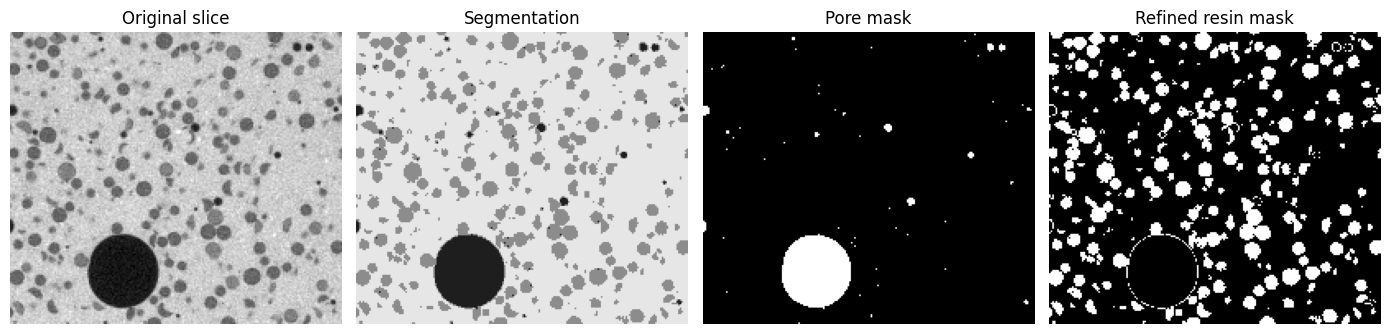

In [10]:
# Visual check of exported image types

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

axes[0].imshow(test_original, cmap="gray")
axes[0].set_title("Original slice")
axes[0].axis("off")

axes[1].imshow(phase_labels_to_rgb(test_labels))
axes[1].set_title("Segmentation")
axes[1].axis("off")

axes[2].imshow(test_pores, cmap="gray")
axes[2].set_title("Pore mask")
axes[2].axis("off")

axes[3].imshow(test_resin, cmap="gray")
axes[3].set_title("Refined resin mask")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## 5. Export selected slice images

This section exports the selected representative slices as PNG images.

For each selected slice, four image types are saved:

- original slice,
- segmentation map,
- pore mask,
- refined resin mask.

An `image_index.csv` table is also created to link each image path with its corresponding `slice_id` and image type.

In [11]:
# Export selected slice images and build image index

# Remove previous test folder from the final index
final_image_dir = IMAGE_OUTPUT_DIR / "selected_slices"
final_image_dir.mkdir(parents=True, exist_ok=True)

image_records = []

for slice_id in selected_slices:
    # Load original TIFF slice
    original_slice = np.array(Image.open(tif_files[slice_id]))

    # Load corresponding segmentation arrays
    label_slice = phase_labels[slice_id]
    pore_slice = pores_mask[slice_id]
    resin_slice = resin_mask[slice_id]

    # Define output paths
    original_path = final_image_dir / f"slice_{slice_id:04d}_original.png"
    segmentation_path = final_image_dir / f"slice_{slice_id:04d}_segmentation.png"
    pore_mask_path_out = final_image_dir / f"slice_{slice_id:04d}_pore_mask.png"
    resin_mask_path_out = final_image_dir / f"slice_{slice_id:04d}_resin_mask.png"

    # Save images
    save_grayscale_png(original_slice, original_path)
    save_segmentation_png(label_slice, segmentation_path)
    save_binary_mask_png(pore_slice, pore_mask_path_out)
    save_binary_mask_png(resin_slice, resin_mask_path_out)

    # Store records for Power BI image index
    image_records.extend(
        [
            {
                "slice_id": slice_id,
                "image_type": "original",
                "image_path": str(original_path),
                "image_filename": original_path.name,
            },
            {
                "slice_id": slice_id,
                "image_type": "segmentation",
                "image_path": str(segmentation_path),
                "image_filename": segmentation_path.name,
            },
            {
                "slice_id": slice_id,
                "image_type": "pore_mask",
                "image_path": str(pore_mask_path_out),
                "image_filename": pore_mask_path_out.name,
            },
            {
                "slice_id": slice_id,
                "image_type": "resin_mask",
                "image_path": str(resin_mask_path_out),
                "image_filename": resin_mask_path_out.name,
            },
        ]
    )

image_index = pd.DataFrame(image_records)

print("Number of selected slices:", len(selected_slices))
print("Number of exported image records:", len(image_index))
print("Expected number of records:", len(selected_slices) * 4)

display(image_index.head(12))

Number of selected slices: 26
Number of exported image records: 104
Expected number of records: 104


,slice_id,image_type,image_path,image_filename
0,0,original,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_original.png
1,0,segmentation,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_segmentation.png
2,0,pore_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_pore_mask.png
3,0,resin_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_resin_mask.png
4,1,original,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0001_original.png
5,1,segmentation,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0001_segmentation.png
6,1,pore_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0001_pore_mask.png
7,1,resin_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0001_resin_mask.png
8,2,original,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0002_original.png
9,2,segmentation,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0002_segmentation.png


In [12]:
# Add slice metadata to image index

image_index = (
    image_index
    .merge(
        dim_slice[
            [
                "slice_id",
                "z_um",
                "z_mm",
                "relative_depth_percent",
                "slice_zone",
            ]
        ],
        on="slice_id",
        how="left"
    )
    .merge(
        fact_slice_features[
            [
                "slice_id",
                "pore_fraction",
                "resin_fraction",
                "matrix_fraction",
                "heterogeneity_index",
            ]
        ],
        on="slice_id",
        how="left"
    )
    .merge(
        fact_anomaly_results[
            [
                "slice_id",
                "anomaly_flag",
                "anomaly_status",
                "anomaly_score",
                "anomaly_category",
            ]
        ],
        on="slice_id",
        how="left"
    )
)

print("image_index shape:", image_index.shape)
print("Image types:")
print(image_index["image_type"].value_counts())

print("\nMissing values per column:")
print(image_index.isna().sum())

display(image_index.head())

image_index shape: (104, 16)
Image types:
image_type
original        26
segmentation    26
pore_mask       26
resin_mask      26
Name: count, dtype: int64

Missing values per column:
slice_id                  0
image_type                0
image_path                0
image_filename            0
z_um                      0
z_mm                      0
relative_depth_percent    0
slice_zone                0
pore_fraction             0
resin_fraction            0
matrix_fraction           0
heterogeneity_index       0
anomaly_flag              0
anomaly_status            0
anomaly_score             0
anomaly_category          0
dtype: int64


,slice_id,image_type,image_path,image_filename,z_um,z_mm,relative_depth_percent,slice_zone,pore_fraction,resin_fraction,matrix_fraction,heterogeneity_index,anomaly_flag,anomaly_status,anomaly_score,anomaly_category
0,0,original,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_original.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
1,0,segmentation,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_segmentation.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
2,0,pore_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_pore_mask.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
3,0,resin_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_resin_mask.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
4,1,original,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0001_original.png,80.0,0.08,0.230415,bottom_0_25,0.049366,0.302342,0.638364,0.241253,1,Anomalous,0.224484,high_porosity+resin_rich+resin_fragmented+larg...


In [13]:
# Export image index table for Power BI

image_index_path = DASHBOARD_EXPORTS / "image_index.csv"
image_index.to_csv(image_index_path, index=False)

print("Saved image index:")
print(image_index_path)

print("\nPreview:")
display(pd.read_csv(image_index_path).head())

Saved image index:
C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports\image_index.csv

Preview:


,slice_id,image_type,image_path,image_filename,z_um,z_mm,relative_depth_percent,slice_zone,pore_fraction,resin_fraction,matrix_fraction,heterogeneity_index,anomaly_flag,anomaly_status,anomaly_score,anomaly_category
0,0,original,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_original.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
1,0,segmentation,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_segmentation.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
2,0,pore_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_pore_mask.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
3,0,resin_mask,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0000_resin_mask.png,0.0,0.00,0.000000,bottom_0_25,0.056875,0.303065,0.622066,0.231376,1,Anomalous,0.232357,high_porosity+resin_rich+resin_fragmented+larg...
4,1,original,C:\Users\Peter\ai-imaging-portfolio\projects\0...,slice_0001_original.png,80.0,0.08,0.230415,bottom_0_25,0.049366,0.302342,0.638364,0.241253,1,Anomalous,0.224484,high_porosity+resin_rich+resin_fragmented+larg...


In [14]:
# Final verification of exported PNG images

png_files = sorted(final_image_dir.glob("*.png"))

print("PNG files in selected_slices folder:", len(png_files))
print("Image index records:", len(image_index))
print("Expected PNG files:", len(selected_slices) * 4)

print("\nImage type counts:")
print(image_index["image_type"].value_counts())

print("\nFirst exported files:")
for file in png_files[:12]:
    print(file.name)

print("\nLast exported files:")
for file in png_files[-12:]:
    print(file.name)

# Check that every path in image_index exists
image_index["image_exists"] = image_index["image_path"].apply(lambda x: Path(x).exists())

print("\nImage path existence:")
print(image_index["image_exists"].value_counts())

missing_images = image_index.loc[~image_index["image_exists"], ["slice_id", "image_type", "image_path"]]

if len(missing_images) > 0:
    print("\nMissing images:")
    display(missing_images)
else:
    print("\nAll indexed images exist.")

PNG files in selected_slices folder: 104
Image index records: 104
Expected PNG files: 104

Image type counts:
image_type
original        26
segmentation    26
pore_mask       26
resin_mask      26
Name: count, dtype: int64

First exported files:
slice_0000_original.png
slice_0000_pore_mask.png
slice_0000_resin_mask.png
slice_0000_segmentation.png
slice_0001_original.png
slice_0001_pore_mask.png
slice_0001_resin_mask.png
slice_0001_segmentation.png
slice_0002_original.png
slice_0002_pore_mask.png
slice_0002_resin_mask.png
slice_0002_segmentation.png

Last exported files:
slice_0414_original.png
slice_0414_pore_mask.png
slice_0414_resin_mask.png
slice_0414_segmentation.png
slice_0415_original.png
slice_0415_pore_mask.png
slice_0415_resin_mask.png
slice_0415_segmentation.png
slice_0434_original.png
slice_0434_pore_mask.png
slice_0434_resin_mask.png
slice_0434_segmentation.png

Image path existence:
image_exists
True    104
Name: count, dtype: int64

All indexed images exist.


## 6. Notebook summary

This notebook exported representative microCT slice images for the Power BI dashboard.

The exported image set includes:

- original tomographic slices,
- 3-class segmentation maps,
- pore masks,
- refined resin masks.

A total of **26 representative slices** were selected using:

- fixed reference positions,
- highest anomaly scores,
- highest pore fractions,
- highest resin fractions,
- representative normal slices across the volume.

For each selected slice, four PNG images were exported, producing **104 images** in total.

The `image_index.csv` table links each image to:

- `slice_id`,
- image type,
- image path,
- depth position,
- phase fractions,
- heterogeneity index,
- anomaly score,
- anomaly category.

This table will be used in Power BI to build an interactive slice explorer.

In [15]:
# Final notebook summary

print("Slice image export completed successfully.\n")

print(f"Selected slices: {len(selected_slices)}")
print(f"Exported PNG images: {len(png_files)}")
print(f"Image index records: {len(image_index)}")

print("\nImage types:")
print(image_index["image_type"].value_counts())

print("\nSelected slice IDs:")
print(selected_slices)

print("\nMain outputs:")
print(final_image_dir)
print(image_index_path)

Slice image export completed successfully.

Selected slices: 26
Exported PNG images: 104
Image index records: 104

Image types:
image_type
original        26
segmentation    26
pore_mask       26
resin_mask      26
Name: count, dtype: int64

Selected slice IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 43, 130, 194, 196, 197, 198, 199, 200, 201, 202, 217, 304, 391, 414, 415, 434]

Main outputs:
C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports\slice_images\selected_slices
C:\Users\Peter\ai-imaging-portfolio\projects\05_microct_quality_monitoring_powerbi\data\dashboard_exports\image_index.csv
